In [2]:
#All the imports
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm
from scipy.stats import kurtosis
from scipy.ndimage import maximum_filter, label
import multiprocessing as mp
import os

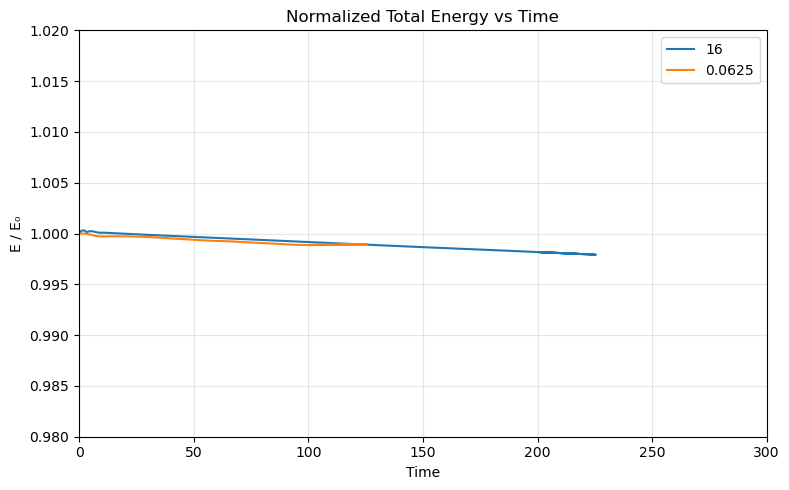

In [3]:
# --- File paths ---
File_Etot = [
    '/DATA/DEVESH/ExtremeBetaSimulations/16/EnTot_ApJ_.h5',
    '/DATA/DEVESH/ExtremeBetaSimulations/0.0625/EnTot_ApJ_.h5'
]

File_Time = [
    '/DATA/DEVESH/ExtremeBetaSimulations/16/Time_ApJ_.h5',
    '/DATA/DEVESH/ExtremeBetaSimulations/0.0625/Time_ApJ_.h5'
]

labels = ['16', '0.0625']

# Helper function to load DS1 from a file
def load_dataset(fp):
    with h5py.File(fp, "r") as f:
        key = list(f.keys())[0]        # get first dataset name, e.g. 'DS1'
        return f[key][:]

# --- Load all runs ---
energies = []
times = []
for efile, tfile in zip(File_Etot, File_Time):
    energies.append(load_dataset(efile))
    times.append(load_dataset(tfile))

# --- Normalize energies ---
normalized = [E / E[0] for E in energies]

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.xlim(0, 300) 
plt.ylim(0.98, 1.02)

for t, Enorm, label in zip(times, normalized, labels):
    plt.plot(t, Enorm, label=label)

plt.xlabel("Time")
plt.ylabel("E / E₀")
plt.title("Normalized Total Energy vs Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("EnergyPlotPpc.png", dpi=300)
plt.show()

In [7]:
# Simulation directories
sim_dirs = [
    '/DATA/DEVESH/ResistivityCheck/0.625e-4',
    '/DATA/DEVESH/ResistivityCheck/1.25e-4',
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048',
    '/DATA/DEVESH/ResistivityCheck/5e-4'
]

dx = 0.0625
dy = 0.0625

for sim_path in sim_dirs:
    # Identify simulation label (last folder name)
    sim_label = os.path.basename(sim_path)

    # File paths
    File_Bx = os.path.join(sim_path, 'Bx_ApJ_t250.h5')
    File_By = os.path.join(sim_path, 'By_ApJ_t250.h5')

    # Read data
    with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy:
        data_Bx = fBx['DS1'][:].T
        data_By = fBy['DS1'][:].T

    # Compute B_perp^2
    data_Bp = data_Bx**2 + data_By**2

    # Plot
    plt.figure(figsize=(10, 8))
    img = plt.imshow(data_Bp, cmap='plasma', vmax=0.5,
                     extent=[0, data_Bp.shape[1]*dx, 0, data_Bp.shape[0]*dy],
                     origin='lower')

    plt.colorbar(img)
    plt.title(r'$|B_\perp|^2$' + f"  (sim: {sim_label})")
    plt.xlabel(r'$x/d_{p}$')
    plt.ylabel(r'$y/d_{p}$')

    plt.tight_layout()
    outname = f"B_{sim_label}.png"
    plt.savefig(outname, dpi=300)
    plt.close()

    print(f"Saved: {outname}")

Saved: B_0.625e-4.png
Saved: B_1.25e-4.png
Saved: B_2.5e-4_2048.png
Saved: B_5e-4.png
